#  AE2 - Data Analysis

## References
#### Python official documentation — csv module, https://docs.python.org/3/library/csv.html)
#### Matplotlib - https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html
#### Pandas - https://pandas.pydata.org/docs/
#### Week 7 Lecture. Programming with Data. Retrieved from https://nulondon.instructure.com/courses/6421/pages/week-7-lecture?module_item_id=431612
#### Week 10 Lab Solutions. Programming with Data. Retrieved from: https://nulondon.instructure.com/courses/6421/pages/week-10-lab-solutions?module_item_id=444147
#### Connected Nations Report - OFC 

### Importing Required Modules

In [2]:
import pandas as pd
import matplotlib as plt

 ### Loading the Data

In [3]:
# 1) LOADING COVERAGE DATA

# Loading 2018 
c18 = pd.read_csv('ofcom/2018/201809_fixed_laua_coverage_r01.csv')
c18['Year'] = 2018   # Adding column to track the year

# Loading 2019
c19 = pd.read_csv('ofcom/2019/201909_fixed_laua_coverage_r01.csv') 
c19['Year'] = 2019  # Adding column to track the year

# Loading 2020
c20 = pd.read_csv('ofcom/2020/202009_fixed_laua_coverage_r01.csv')
c20['Year'] = 2020  # Adding column to track the year

# Loading 2021
c21 = pd.read_csv('ofcom/2021/202109_fixed_laua_coverage_r01.csv')
c21['Year'] = 2021

# Load 2022
c22 = pd.read_csv('ofcom/2022/202209_fixed_laua_coverage_r02.csv')
c22['Year'] = 2022

# Load 2023
c23 = pd.read_csv('ofcom/2023/202309_fixed_laua_coverage_r01.csv')
c23['Year'] = 2023

# Load 2024
c24 = pd.read_csv('ofcom/2024/202407_fixed_laua_coverage_r01.csv')
c24['Year'] = 2024

# Stacking them togeather
df_coverage = pd.concat([c18, c19, c20, c21, c22, c23, c24])


# 2) LOADING PERFORMANCE DATA

# Loading 2018 
p18 = pd.read_csv('ofcom/2018/201805_fixed_laua_performance_r02.csv')
p18['Year'] = 2018

# Loading 2019
p19 = pd.read_csv('ofcom/2019/201905_fixed_laua_performance_r01.csv')
p19['Year'] = 2019

# Loading 2020
p20 = pd.read_csv('ofcom/2020/202006_fixed_laua_performance_r02.csv')
p20['Year'] = 2020

# Loading 2021
p21 = pd.read_csv('ofcom/2021/202105_fixed_laua_performance_r01.csv')
p21['Year'] = 2021

# Loading 2022
p22 = pd.read_csv('ofcom/2022/202205_fixed_laua_performance_r02.csv')
p22['Year'] = 2022

# Loading 2023
p23 = pd.read_csv('ofcom/2023/202305_fixed_laua_performance_r01.csv')
p23['Year'] = 2023

# Loading 2024
p24 = pd.read_csv('ofcom/2024/202407_fixed_performance_laua_r01.csv')
p24['Year'] = 2024

# Stacking them togeather
df_performance = pd.concat([p18, p19, p20, p21, p22, p23, p24])

In [4]:
# 3) PREPARING THE LOOKUP TABLE
# Reading the file
df_lookup = pd.read_csv('ons/Ward_to_Local_Authority_District_to_CTYUA_to_RGN_to_CTRY_May_2024_Lookup_in_UK.csv')

# Keeping only the Authority Code, Region, and Country
df_lookup = df_lookup[['LAD24CD', 'RGN24NM', 'CTRY24NM']]

# Removing duplicates so we have 1 row per Authority
df_lookup = df_lookup.drop_duplicates(subset=['LAD24CD'])


# COVERAGE MERGE
df_cov_final = pd.merge(
    df_coverage, 
    df_lookup, 
    left_on='laua', 
    right_on='LAD24CD', 
    how='inner'
)

# PERFORMANCE MERGE
df_perf_final = pd.merge(
    df_performance, 
    df_lookup, 
    left_on='laua', 
    right_on='LAD24CD', 
    how='inner'
)



# Show the first few rows to prove 'Year' and 'Region' are both there
display(df_cov_final[['Year', 'laua', 'RGN24NM', 'CTRY24NM']].head())

,Year,laua,RGN24NM,CTRY24NM
0,2018,S12000033,NaN,Scotland
1,2018,S12000034,NaN,Scotland
2,2018,E07000223,South East,England
3,2018,E07000032,East Midlands,England
4,2018,S12000041,NaN,Scotland


In [5]:
df_cov_final.head()

,laua,laua_name,All Premises,All Matched Premises,SFBB availability (% premises),UFBB availability (% premises),Full Fibre availability (% premises),% of premises unable to receive 2Mbit/s,% of premises unable to receive 5Mbit/s,% of premises unable to receive 10Mbit/s,...,% of premises with 2<5Mbit/s download speed,% of premises with 5<10Mbit/s download speed,% of premises with 10<30Mbit/s download speed,UFBB (100Mbit/s) availability (% premises),Gigabit availability (% premises),Number of premises with UFBB (100Mbit/s) availability,Number of premises with Gigabit availability,LAD24CD,RGN24NM,CTRY24NM
0,S12000033,Aberdeen City,110735.0,110727.0,88.2,4.8,1.4,0.1,0.2,1.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S12000033,NaN,Scotland
1,S12000034,Aberdeenshire,120382.0,120382.0,77.1,1.2,1.2,3.1,7.1,11.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S12000034,NaN,Scotland
2,E07000223,Adur,29094.0,29054.0,32.5,66.6,0.1,0.0,0.1,0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E07000223,South East,England
3,E07000032,Amber Valley,59201.0,59200.0,70.2,22.0,19.6,0.2,0.8,1.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E07000032,East Midlands,England
4,S12000041,Angus,56859.0,56859.0,70.8,15.3,0.8,1.4,3.6,7.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S12000041,NaN,Scotland


## 1. Trend Analysis
#### Question 1: How has the coverage and performance changed over time ?

This analysis groups the coverage data by year to visualize the trajectory of infrastructure improvements and performance enhancements. The distribution of Superfast network coverage and download speeds is used as a metric to assess progress over time.

In [6]:
df_cov_final.dtypes['SFBB availability (% premises)'] # Ensuring the datatype is float for matematical calculations

dtype('float64')

In [7]:
national_trend_cov = df_cov_final.groupby('Year')['SFBB availability (% premises)'].mean() # Calculating the average Superfast network availability across the UK for each year
national_trend_cov

Year
2018    46.798555
2019    44.976554
2020    94.343380
2021    94.517647
2022    95.467507
2023    96.280952
2024    96.734626
Name: SFBB availability (% premises), dtype: float64

Matplotlib is building the font cache; this may take a moment.


Text(0, 0.5, 'Availability (%)')

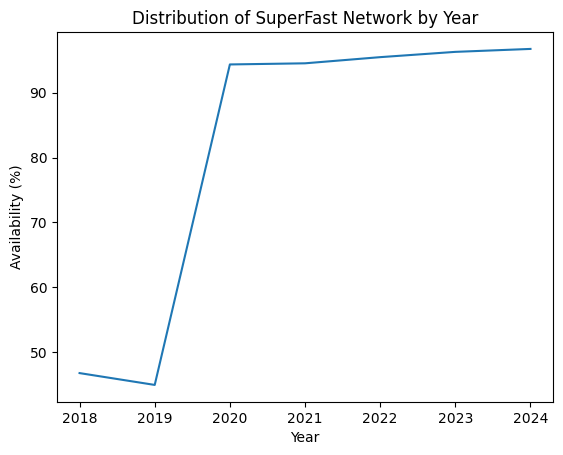

In [8]:
# Plotting the national coverage trend over time
ax = national_trend_cov.plot()

ax.set_title('Distribution of SuperFast Network by Year')
ax.set_ylabel('Availability (%)')

In [11]:
national_trend_perf

Year
2018     47.492486
2019     59.118927
2020     69.647606
2021     83.725210
2022    107.670588
2023    147.198599
2024           NaN
Name: Average download speed (Mbit/s), dtype: float64

<Axes: title={'center': 'Trend of Average UK Download Speed (2018-2023)'}, xlabel='Year', ylabel='Average Download Speed (Mbit/s)'>

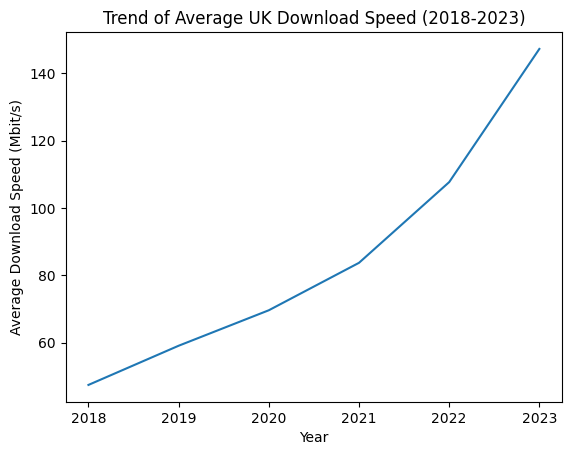

In [10]:
# Plotting the national coverage trend over time
national_trend_perf = df_perf_final.groupby('Year')['Average download speed (Mbit/s)'].mean()
national_trend_perf.plot(ylabel = 'Average Download Speed (Mbit/s)', title = 'Trend of Average UK Download Speed (2018-2023)')

## 2. Comparison Analysis
#### Question 2: Which Local Authorities achieved the highest average download speeds in 2023?

This analysis filters for the year 2023 (to ensure data consistency) and ranks the top 10 Local Authorities to identify high-performance areas.

In [29]:
speed_col = 'Average download speed (Mbit/s)'

# Getting the top 10 authorities with highest download speeds
top_10 = df_perf_final[df_perf_final['Year'] == 2023].nlargest(10, speed_col)[['laua_name', 'CTRY24NM', speed_col]]
top_10

,laua_name,CTRY24NM,Average download speed (Mbit/s)
1876,EASTBOURNE,England,780.2
2049,SOUTHAMPTON,England,279.3
2060,STOCKTON-ON-TEES,England,248.6
1790,BELFAST,Northern Ireland,218.6
1881,EPSOM AND EWELL,England,217.0
1809,"BRISTOL, CITY OF",England,208.3
2079,THREE RIVERS,England,207.5
1867,EAST DUNBARTONSHIRE,Scotland,205.3
1962,MIDDLESBROUGH,England,205.0
1851,DARLINGTON,England,204.5


<Axes: xlabel='Average download speed', ylabel='laua_name'>

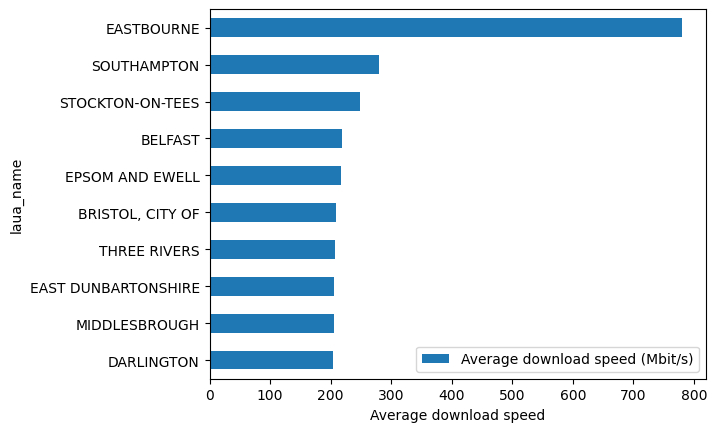

In [30]:
# Plotting the top 10 authorities with highest download speeds in 2023
top_10.sort_values("Average download speed (Mbit/s)", ascending=True).plot(kind="barh", x ="laua_name", xlabel = "Average download speed" )

## 3. Relationship Analysis
#### Question 3: Is there a correlation between Gigabit infrastructure availability and actual download speeds in 2023?

This scatter plot tests the hypothesis that areas with higher Gigabit (Full Fibre) availability actually experience faster speeds.

<Axes: xlabel='Gigabit availability (% premises)', ylabel='Average download speed (Mbit/s)'>

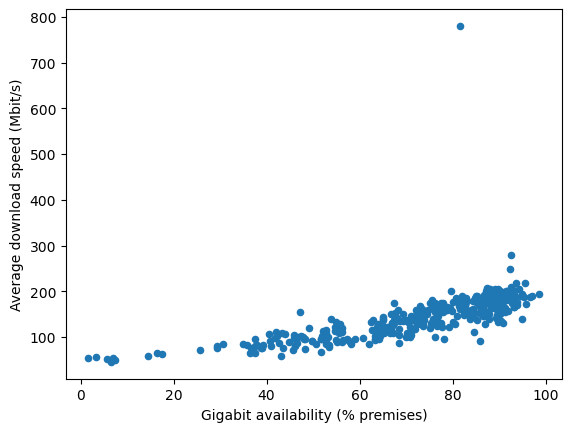

In [31]:
merged_23 = pd.merge(c23, p23, on='laua') # Preparing Data : Joining 2023 Coverage and Performance data on Area code('laua')

# Plotting the Data
merged_23.plot(x = 'Gigabit availability (% premises)', y = "Average download speed (Mbit/s)", kind = "scatter")

## 4. Regional Disparity Analysis
#### Question 4: Are there regional disparities in the rollout of Gigabit broadband in 2024?

We compare the average Gigabit availability of each Region against the overall UK National Average to identify areas that are lagging behind.

National Average: 79.37%
Gap between Top (Northern Ireland) and Bottom (Scotland): 24.68%


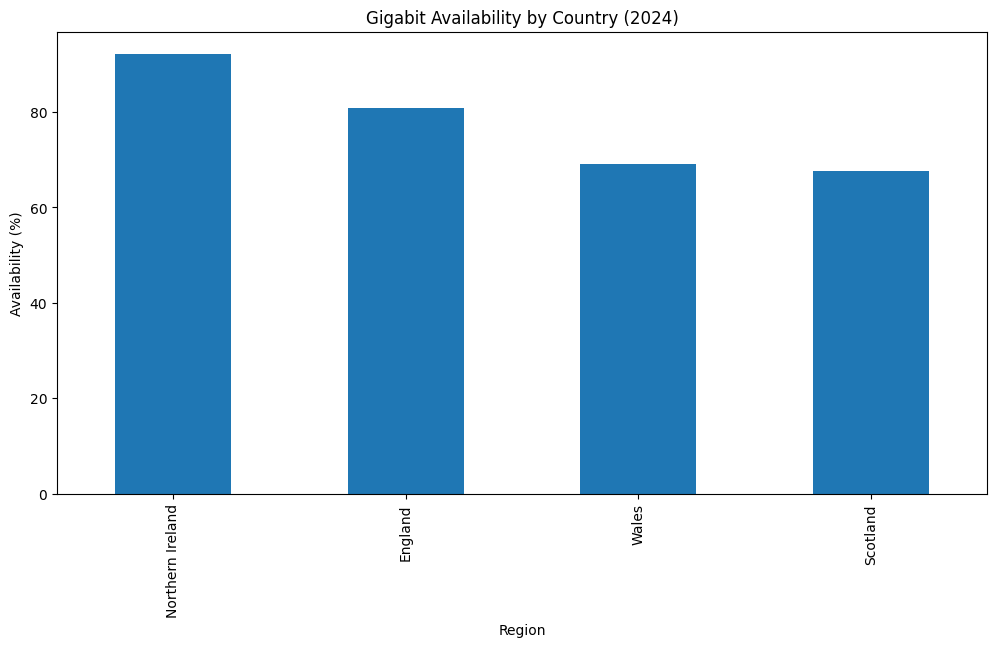

In [37]:
# Finding the Gigabit column name 
gig_col = [c for c in df_cov_final.columns if 'Gigabit' in c][0]

# Calculating Regional Means (sorted)
regional_stats = df_cov_final[df_cov_final['Year'] == 2024].groupby('CTRY24NM')[gig_col].mean().sort_values()

# Calculating UK National Average for benchmarking
national_avg = df_cov_final[df_cov_final['Year'] == 2024][gig_col].mean()


# Visualizing the Data
regional_stats.sort_values(ascending = False).plot(kind = "bar", figsize=(12, 6), title = 'Gigabit Availability by Country (2024)', ylabel = 'Availability (%)', xlabel = 'Region', )

# Printing out the national average and the gap
print(f"National Average: {national_avg:.2f}%")
print(f"Gap between Top ({regional_stats.index[-1]}) and Bottom ({regional_stats.index[0]}): "
      f"{regional_stats.max() - regional_stats.min():.2f}%")

In [36]:
regional_stats

CTRY24NM
Scotland            67.559375
Wales               69.145455
England             80.933446
Northern Ireland    92.236364
Name: Gigabit availability (% premises), dtype: float64

# REPORT

#### 1. INTRODUCTION 
This report provides a comprehensivel analysis of the fixed broadband infrastructure in the United Kingdom, between 2018 and 2024. Data files from OFCOM’s Connected Nations reports and ONS geographic lookup tables were leveraged to assess broadband rollout across the UK.
It answers four main research questions: what is the trend of coverage and performance, which authorities are achieving highest speeds, what is the correlation between infrastructure and speed, and how wide are regional disparities.
Key findings show that the rollout of “Superfast” broadband has reached its peak, with coverage growth slowing down after 2021. Broadband performance has kept improving, mostly because more Gigabit-enabled networks are being built. There is a clear link between better infrastructure and faster broadband speeds, but large differences between regions still exist. The data highlight a clear “digital divide,” as some rural areas, especially in Wales, have less access to Gigabit broadband compared to top urban areas and government-backed projects in Northern Ireland.


#### 2. Methodology and Data Preparation
Data analysis was performed in Python with pandas libraries employed for data manipulation and matplotlib for data visualization. This section discusses the data ingestion process and the cleaning process that made geographic aggregation feasible.

##### 2.1. Data Ingestion Strategy
To ensure each dataset was accurate and validated, the data was loaded manually. pd.read_csv function was used to read all fourteen CSV files( 7 of Coverage and 7 of Performance). During loading, a 'Year' column was added to each dataframe. Since the datasets used the same structure and column headers each year, they could be easily combined into one final dataframe covering all years using .concat() function.

##### 2.2. Data Cleaning
Although the main OFCOM data were mostly structured and consistent, there was a significant data issue seen in the ONS Lookup Table. Wards were mapped to local government areas in the included lookup file. LAD24CD codes (Local Authority codes) were mentioned many times in the file as one Local Authority has several Wards. Had the raw file and broadband data been combined, the broadband records for every ward in the city would have been duplicated into a "One-to-Many" join. In order to avoid it, I created a unique register of Local Authorities in the lookup table using drop_duplicates. This ensured that the merge had a clean "One-to-One" relationship.

##### 2.3.The 2024 Performance Data Decision
In the exploration stage, an anomaly was discovered in the dataset of 2024 Performance. In comparison to the past trends, the Performance data of 2024 seemed to possess an anomaly, although the Coverage data seemed to be flawless. Such critical data as average, minimum and maximum upload and download speeds were absent.
This may be due to the fact that the data collection procedures of the said year were not similar or the reporting cycles were not finalized.
To maintain the statistical validity of the report, I decided to take 2023 statistics as the standard of performance related analyses such as average download speed and the Top 10 ranking. Only the 2024 data was referred to in the coverage analysis. This division employed the most stable dataset (2023) as the benchmark performance so that the report indicates the latest infrastructure status (2024).





#### 3.Data Analysis and Findings
This section presents the results of the four specific analyses conducted to address the project objectives.

##### 3.1. Trend Analysis
**Question:**  How has the coverage and performance changed over time ?
This analysis combines two metrics to evaluate progress: the availability of "Superfast" broadband (>30 Mbit/s) and the growth in average download speeds. A line chart was chosen as it is the industry standard for time-series data, giving the ability to check for growth trend, plateau or changing trends over the six-year period.

Findings: 

Blistering Growth in coverage: The average coverage of 2018-2019 was 44-46%, but in 2020, it grew by far to 94%. Such a sudden shift can mainly be attributed to the methodological re-baselining of OFCOM which consisted of reclassification of current VDSL capacity and associated counting premises with the Ordnance Survey information instead of just relying on new physical infrastructure. Once this data is adjusted the trend becomes stabilised and saturated between 2021 and 2024 at 95-98% level. Such plateau implies that commercial launch of Superfast broadband is near to full, with the remaining gaps happening in the rural areas that are geographically challenging.

Performance Acceleration: Compared to the plateauing curve of coverage, the trend of the Average Download Speed, examined up to 2023, will exhibit continuous and speeding expansion. The overall speed in the country has increased over two times over the period of observation.

Interpretation: The fact that the flattening line representing the Superfast Coverage crosses the line upward making the Speed line is important. It implies that the growth is no longer through reaching out to people who are not online yet, but through upgrading existing connections to more performant technologies, including Full Fibre or Gigafibre. The "Superfast" parameter is no longer the primary catalyst of change, since the market currently focuses on the capacity and actual performance improvements.


##### 3.2. Comparison Analysis
**Question:** Which Local Authorities achieved the highest average download speeds?
The comparison analysis was performed using the performance-verified 2023 performance dataset to rank the UK Local Authorities based on the average download speed.

Findings: The ranking reveals that high network performance does not directly correlate with population size. The top ten Local Authorities are primarily characterized by unique infrastructure features rather than being major capital cities. A horizontal bar chart was selected because it bests suits the data and is easily readable.
The table describes the 10 local authorities that have the highest average download speeds in 2023. Eastbourne is substantially high and has recorded the highest speed of 780.2 Mbit/s which is way above the other areas. Others like Southampton, Stockton-on-Tees and Belfast come next with speeds of between 218-279 Mbit/s. The other authorities, namely Epsom and Ewell, Bristol, Three Rivers, East Dunbartonshire, Middlesbrough and Darlington, only have speeds of slightly over 200 Mbit/s. In general, the graph shows the high gap between the number one authority and the other regions with the highest performance.


The Eastbourne anomaly: Eastbourne is a major outlier, with average download speeds of 780.2 Mbits/s meaning it is quite high compared to other Local Authorities. Additional research based on the data of the Connected Nations presented by Ofcom indicates that the current achievements of Eastbourne could be explained by the fact that it is the head office and the main location of deployment of Lightning Fibre that was introduced by an Alt Net provider. Unlike national providers, who deploy a standard fibre, Lightning Fibre has introduced a 10Gbps-capable network across the town on a symmetric basis. This confirms that the areas in the UK with the highest speed of broadband are not the biggest cities like London, or Birmingham, but are usually specific towns which are targeted by the companies which are providing fibre privately. Competition by the private sector has led to Eastbourne emerging as a Gigabit island with speeds upto 8x faster than UK's average

This confirms that the quickest broadband locations in the UK do not always take place in the largest cities, including London or Birmingham, but can be instead a definite town that is targeted by the private fibre firms. Eastbourne is a Gigabit Island, where the private sector competition has seen the speed being five to eight times greater than the national average.

Interpretation: The comparison highlights a significant difference in the user experience. Although the average download speed in the country reached about 147.20 Mbit/s in 2023, locations that are ranked number 10 and above offer speeds that are favorable to advanced online actions, such as instantaneous large file transfer and 8K streaming. These findings suggest the creation of a two-tier internet: distinct 'gigabit islands' with competition between infrastructure providers improving speeds, and the rest of the country using conventional national rollouts.

##### 3.3.Relationship Analysis
**Question:** Is there a correlation between Gigabit infrastructure availability and actual download speeds?
One of the assumptions of the broadband policy is that the construction of infrastructure will have positive results.To check this, a scatter plot was made between gigabit availability and average 2023 download speed. Scatter plot has been chosen to demonstrate the data since it is the most appropriate means of determining the relationship between the data.

Results: The results of the scatter plot indicate a positive correlation. Local Authorities that have greater shares of Gigabit availability always record larger average download speeds. The Trend: The regression line indicates that, as infrastructure availability increases significantly in every observation, the speeds that the users get increases in a measurable fashion.
The Trend: The regression line shows that for every significant increase in infrastructure availability, there is a measurable increase in the speeds users experience.

The Lag: The association is however not linear. The data points on the bottom-right quadrant describe the regions that have high Gigabit but moderate speeds.

Interpretation: The fact that we got a positive correlation supports the current practice of making an investment in infrastructure by proving that the growth of the network results in a higher speed. Other outliers are however indicative of an Adoption Lag. Users do not necessarily upgrade immediately after installation of Gigabit fibre. This could be due to any existing contracts/ agreements or apprehensions of paying higher to get higher speed. These findings demonstrate that it is not only an engineering task to make the network available, but it is also important in the work of the network in practice due to economic factors and consumer behavior.

##### 3.4.Regional Disparity Analysis
**Question:** Are there regional disparities in the rollout of Gigabit broadband?
The last analysis involved investigating the equity of the rollout by comparing the availability of Gigafit in 2024 in the various UK Regions with the National Average.  A bar chart was chosen for visualization as it cleary shows the gap between each countries, effecively visualizing disparity.

Findings: The analysis reveals stark geographic inequalities:

The bar chart shows the availability of the gigabit broadband in the four UK countries. The Northern Ireland is far ahead with the highest availability at 92.23% compared to the other regions. England comes second with 80.9% and the coverage is great, but relatively less. The availability rates in Wales and Scotland are equivalent (69.1% and 67.6% respectively) and significantly less than the national average of 79.37%, which means that the nationwide rollout is slower. On the whole, the graph shows the distinct difference in the provision of gigabit broadband in regions within the UK.

Northern Ireland’s success is particularly notable given its rural geography, pointing to the impact of specific government interventions (Project Stratum).
Conversely, Wales and Scotland lag significantly behind. The disparity gap calculated between the best-served region and the worst-served region is 24.68%

Interpretation A strong national disparity is indicated in digital infrastructure through this analysis. The excellent performance of Northern Ireland has shown how public subsidies targeted at specific regions can successfully deal with the problem of rural areas, whereas England enjoys good commercial rollout because of its population density. Scotland and Wales, however, are far below the national average, which demonstrates the disadvantages of a pure market-based approach in the geographically problematic regions. The fact that the most connected and least connected countries are at the estimated difference of 24.68 percent is a clear indication that even though the roll out was effective overall, it is not fairly represented at the national level.



#### 4.Conclusion
To sum up, the analysis of the data provided by the OFCOM outlines the UK broadband process as a technical success with a significant geographic unequal distribution.

As Superfast coverage saturates at [97-98%], the research proves the point that the days of the plain Access are virtually gone. The new frontier is at the Capacity which is seeing national performance of an infrastructure that is strongly correlated with download speeds of gigabit infrastructure. Nevertheless, the so-called Adoption Gap remains visible: even in locations that have high connectivity, a significant number of users still operate with slower connections, which suggests a lack of financial means to do so. Most significantly, the rollout continues to have a 24.68% gap between the digital leaders ( England/ Northern Ireland ) and the laggards ( Wales/ Scotland ).

Ethical Data Use and Safety: There were stringent measures in the course of the project to ensure safe and ethical data management. There was no risk to any individual privacy as the analysis utilized nothing more than publicly available open-source data which was given in the assignment. I also ensured that discoveries and results were not published to an individual or institutions prior to submission.
